In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Cube.AI/tof.csv', sep=',', skiprows=1, header=None, on_bad_lines='warn', engine='python')

/tmp/ipykernel_7841/2115073629.py:2: ParserWarning: Skipping line 3: Expected 30 fields in line 3, saw 42

  df = pd.read_csv('/content/drive/MyDrive/Cube.AI/tof.csv', sep=',', skiprows=1, header=None, on_bad_lines='warn', engine='python')


In [ ]:
df = df.replace(1200, method='ffill')

/tmp/ipykernel_7841/57598395.py:1: FutureWarning: The 'method' keyword in DataFrame.replace is deprecated and will be removed in a future version.
  df = df.replace(1200, method='ffill')


In [ ]:
df_normalized = df / 1200.0

### 1. Preparing Data for a PyTorch Model

First, we need to get our `df_normalized` data ready for PyTorch. This involves handling any remaining missing values, converting the DataFrame to a PyTorch tensor, and then creating sequences for our model to learn from. An LSTM model typically learns by looking at a sequence of past data points to predict future ones.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split

# Handle NaN values
# The last row (index 39) of df_normalized seems to contain many NaNs from the kernel state, so we'll drop it.
data_tensor = torch.from_numpy(df_normalized.dropna().values).float()

# Define a function to create sequences
def create_sequences(data, sequence_length):
    xs = []
    ys = []
    for i in range(len(data) - sequence_length):
        x = data[i:(i + sequence_length)]
        y = data[i + sequence_length] # Predict the next time step
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)

# Define sequence length
SEQUENCE_LENGTH = 5 # How many past timesteps to consider for prediction

X, y = create_sequences(data_tensor, SEQUENCE_LENGTH)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original data shape: {data_tensor.shape}")
print(f"Training input sequences shape: {X_train.shape}") # (num_samples, sequence_length, num_features)
print(f"Training output targets shape: {y_train.shape}") # (num_samples, num_features)


Original data shape: torch.Size([39, 30])
Training input sequences shape: torch.Size([27, 5, 30])
Training output targets shape: torch.Size([27, 30])


### 2. Defining the LSTM Model Architecture

We'll define a simple LSTM model. An LSTM is a type of recurrent neural network capable of learning order dependence in sequence prediction problems. Here, it will take a sequence of movement data and try to predict the next set of movement values.

*   `input_size`: The number of features at each time step (i.e., the number of columns in your data).
*   `hidden_size`: The number of hidden units in the LSTM layer. This is a hyperparameter you can tune.
*   `num_layers`: The number of stacked LSTM layers.
*   `output_size`: The number of features to predict at the next time step (usually the same as `input_size` for sequence prediction).

In [ ]:
class MovementPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=4):
        super(MovementPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 1. FORCE STATIC BATCH SIZE OF 1
        batch_size = 1

        # 2. Use the static integer here so no dynamic tracer is generated
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_size = data_tensor.shape[1] # Number of features
hidden_size = 64
num_layers = 2
output_size = input_size # Predicting all features for the next timestep

model = MovementPredictor(input_size, hidden_size, num_layers, output_size)

# Define Loss function and Optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


MovementPredictor(
  (lstm): LSTM(30, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=30, bias=True)
)


### 3. Training the Model

Now we'll set up a basic training loop. In each epoch, the model will iterate through the training data, make predictions, calculate the loss (how far off its predictions were), and then update its internal weights to try and make better predictions in the future.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

num_epochs = 100

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Create a DataLoader to process data in batches of 1, matching the model's forward method
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True) # Shuffle for better training

print(f"Starting training on device: {device}")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_loss = 0

    for batch_X, batch_y in train_loader:
        # Move batch data to the correct device
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

print("Training complete!")


Starting training on device: cpu
Epoch [10/100], Loss: 0.0104
Epoch [20/100], Loss: 0.0078
Epoch [30/100], Loss: 0.0066
Epoch [40/100], Loss: 0.0058
Epoch [50/100], Loss: 0.0043
Epoch [60/100], Loss: 0.0025
Epoch [70/100], Loss: 0.0015
Epoch [80/100], Loss: 0.0008
Epoch [90/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0003
Training complete!


### 4. Evaluating the Model and Visualizing Predictions

Now that the model is trained, let's see how well it performs on unseen data (the test set). We'll make predictions and then visualize a sample of actual vs. predicted movement patterns.

Test Loss: 0.0126


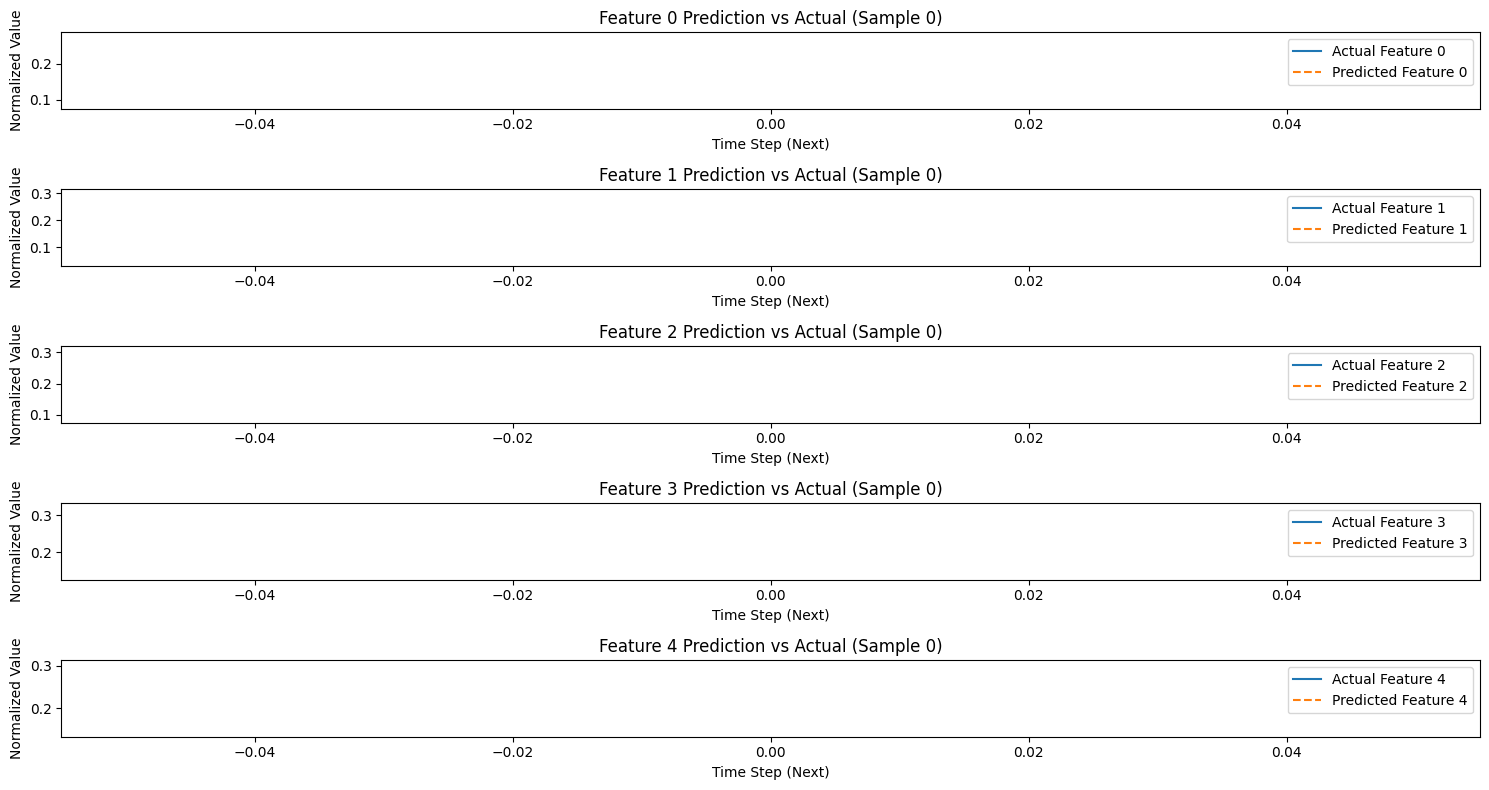

Model evaluation and visualization complete.


In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Set model to evaluation mode
model.eval()

# Create a DataLoader for the test set with batch_size=1
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) # No need to shuffle test data

all_test_predictions = []
all_y_test_batches = []

# Make predictions on the test set batch by batch
with torch.no_grad():
    for batch_X_test, batch_y_test in test_loader:
        # Move batch data to the same device as the model
        batch_X_test, batch_y_test = batch_X_test.to(device), batch_y_test.to(device)

        outputs = model(batch_X_test)
        all_test_predictions.append(outputs.cpu())
        all_y_test_batches.append(batch_y_test.cpu())

# Concatenate all predictions and actuals
stacked_test_predictions = torch.cat(all_test_predictions, dim=0)
stacked_y_test = torch.cat(all_y_test_batches, dim=0)

# Calculate overall test loss
test_loss = criterion(stacked_test_predictions.to(device), stacked_y_test.to(device))

print(f'Test Loss: {test_loss.item():.4f}')

# --- Visualization ---

# Pick a sample from the test set to visualize
sample_index = 0 # You can change this to look at different samples

# Get actual and predicted values for the sample from the stacked tensors
actual_sequence = stacked_y_test[sample_index].numpy()
predicted_sequence = stacked_test_predictions[sample_index].numpy()

# You might have many features (30 in this case), let's plot a few to see the trend
num_features_to_plot = 5

plt.figure(figsize=(15, 8))
for i in range(min(num_features_to_plot, actual_sequence.shape[0])):
    plt.subplot(num_features_to_plot, 1, i + 1)
    plt.plot(actual_sequence[i:i+1], label=f'Actual Feature {i}') # Plot only the predicted point
    plt.plot(predicted_sequence[i:i+1], label=f'Predicted Feature {i}', linestyle='--')
    plt.title(f'Feature {i} Prediction vs Actual (Sample {sample_index})')
    plt.legend()
    plt.xlabel('Time Step (Next)')
    plt.ylabel('Normalized Value')

plt.tight_layout()
plt.show()

print("Model evaluation and visualization complete.")


### 5. Exporting the Model to ONNX Format

To make the model more portable and potentially allow it to run on different inference engines or hardware, we can convert it to the ONNX (Open Neural Network Exchange) format. This involves tracing the model's computation graph with a dummy input.

In [ ]:
# Instantiate fresh
model = MovementPredictor()

# Optional: If you are loading trained weights, do it here
# model.load_state_dict(torch.load("your_trained_weights.pth"))

model.eval()

MovementPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

In [ ]:
# Install onnxscript if it's missing (needed for some PyTorch ONNX exports)
!pip install onnxscript

print("onnxscript installed. Please re-run the ONNX export cell (cell 6604a4d6).")

onnxscript installed. Please re-run the ONNX export cell (cell 6604a4d6).


In [ ]:
import os

# Define the path to save the ONNX model
onnx_model_path = '/content/drive/MyDrive/Cube.AI/movement_predictor.onnx'

#  NEW EXPORT BLOCK
model.eval()

# Shape: [1 batch, 30 time steps, 1 distance feature]
dummy_input = torch.randn(1, 30, 1, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    "movement_predictor_fixed.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input_motion'],
    output_names=['output_scores']
)
print("Static, slice-free ONNX model exported cleanly!")

W0703 17:14:40.418000 7841 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MovementPredictor([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3], self.lstm._flat_weights[4], self.lstm._flat_weights[5], self.lstm._flat_weights[6], self.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `MovementPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/BaseConverter.h:67: adapter_lookup: Assertion `false` failed: 

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Static, slice-free ONNX model exported cleanly!


In [ ]:
import torch
import onnx

model.eval()

# Change this shape based on your model input
# Example for LSTM: batch=1, time_steps=20, features=6
dummy_input = torch.randn(1, 30, 1,dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    "movement_predictor_static.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes=None,
    dynamo=False,
    external_data=False
)

onnx_model = onnx.load("movement_predictor_static.onnx", load_external_data=False)
onnx.checker.check_model(onnx_model)

print("Single ONNX file exported successfully")

Single ONNX file exported successfully


/tmp/ipykernel_7841/2519055724.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4463: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


In [ ]:
from google.colab import files
files.download(onnx_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>